# MDA512 Assignment 2 — Bank Customer Churn Prediction  
**Group Members:Aravind, preeti, prasan, Rohan, Riddhi 
**Dataset:** Churn_Modelling.csv  
**Goal:** Predict which bank customers will leave so the bank can target retention campaigns.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

## Step 1: Load and Inspect the Data

In [4]:
df=pd.read_csv(r"C:\Users\aravi\Downloads\archive (1)\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Check the size of the dataset (rows, columns)
# We expect 10,000 customer records with 14 attributes each
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 10000 rows and 14 columns


In [6]:
# Show the data type of each column and number of non-null values
# This helps identify: numeric vs categorical columns, and any missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
# Explicitly count missing values in each column
# Even though df.info() showed 10000 non-nulls, this gives a clearer picture
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [8]:
# Examine the target variable 'Exited' — this is what we want to predict
# 0 = customer stayed,  1 = customer left (churned)
print("Customer churn distribution:")
print(df["Exited"].value_counts())

# Calculate the churn rate as a percentage
churn_rate = df["Exited"].mean() * 100
print(f"\nChurn rate: {churn_rate:.2f}%")

Customer churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


In [9]:
# Get statistical summary of all numeric columns
# Shows: count, mean, std deviation, min, 25%, 50% (median), 75%, max
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Step 2: Exploratory Data Analysis (EDA)

In this section, we visualise the data to understand patterns and relationships between features and the target variable (`Exited`).

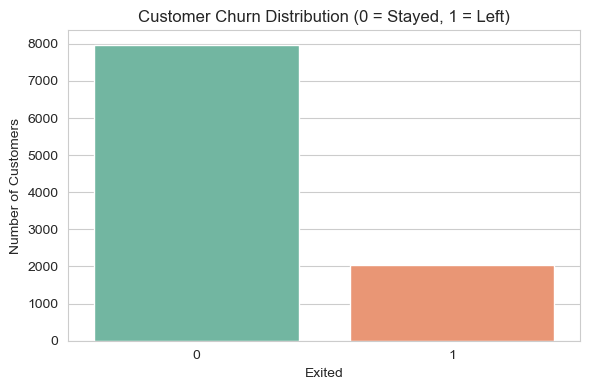

In [10]:
# Plot 1: Distribution of the target variable (Exited)
# Visualises the class imbalance we identified earlier (~80/20 split)

plt.figure(figsize=(6, 4))                              # set figure size (width, height in inches)
sns.countplot(x="Exited", data=df, palette="Set2")      # count plot: bars showing count per category
plt.title("Customer Churn Distribution (0 = Stayed, 1 = Left)")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.tight_layout()                                       # auto-adjusts spacing so labels don't get cut
plt.show()                                               # display the plot in the notebook

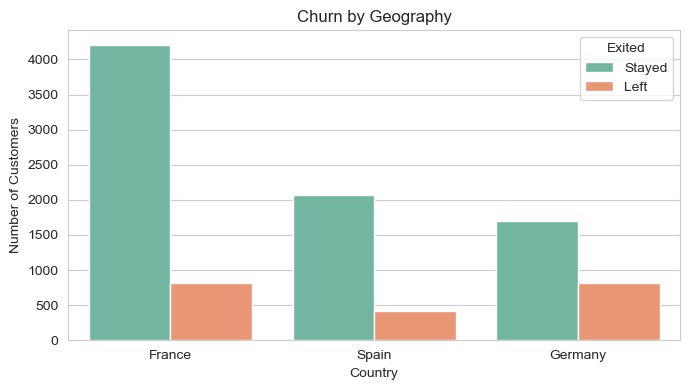

In [39]:
# Plot 2: Churn by Geography
# Investigates whether customers from certain countries are more likely to leave
# This could reveal location-specific issues (e.g., poor service in one country)

plt.figure(figsize=(7, 4))
sns.countplot(x="Geography", hue="Exited", data=df, palette="Set2")
plt.title("Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Stayed", "Left"])    # add custom legend labels
plt.tight_layout()
plt.show()

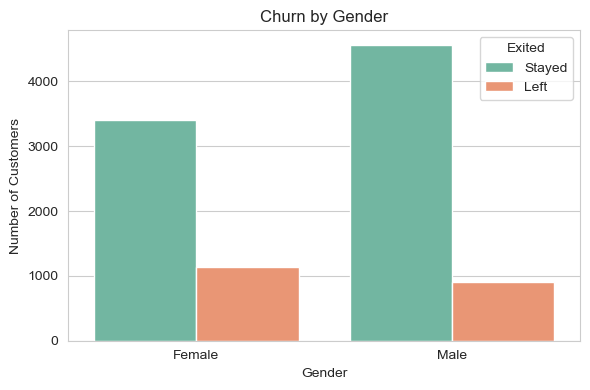

In [40]:
# Plot 3: Churn by Gender
# Investigates whether male or female customers are more likely to leave

plt.figure(figsize=(6, 4))
sns.countplot(x="Gender", hue="Exited", data=df, palette="Set2")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Stayed", "Left"])
plt.tight_layout()
plt.show()

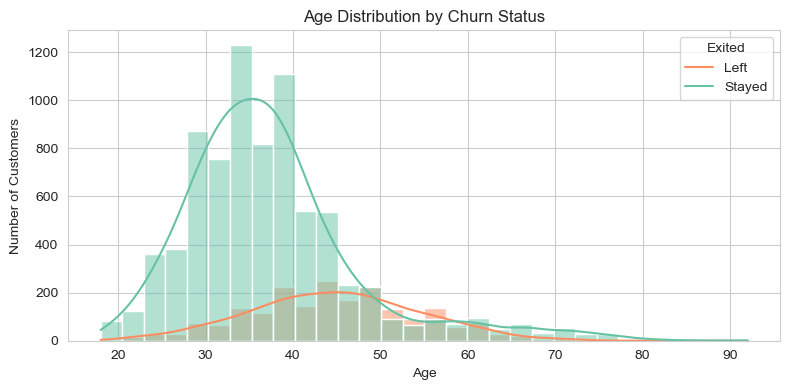

In [41]:
# Plot 4: Age distribution split by churn status
# Uses a histogram to compare the age distributions of customers who stayed vs left
# This is one of the most informative plots — age strongly affects churn!

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Age", hue="Exited", kde=True, palette="Set2", bins=30)
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Left", "Stayed"])
plt.tight_layout()
plt.show()

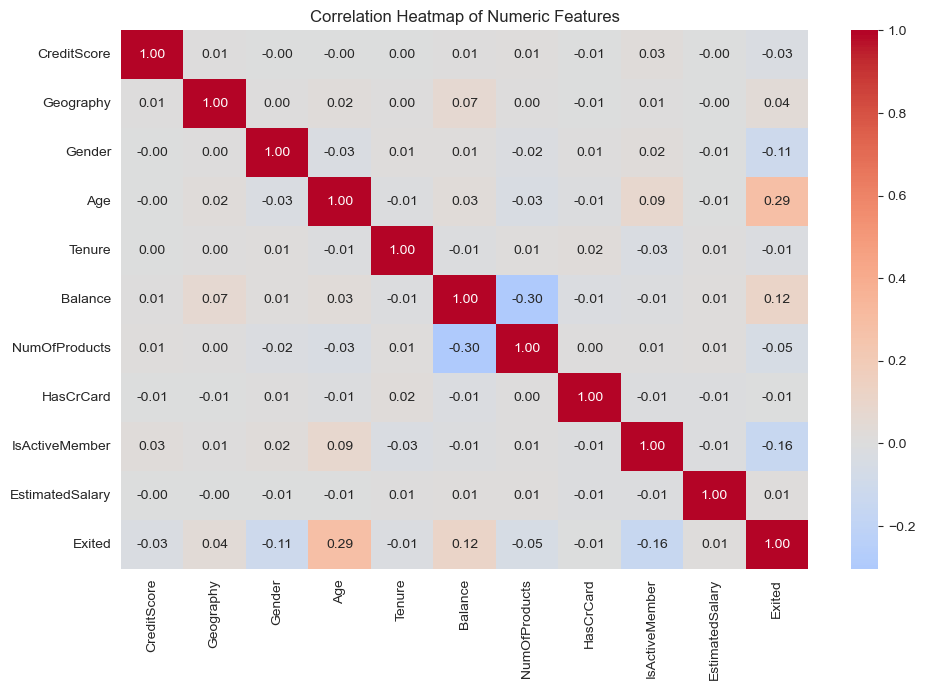

In [32]:
# Plot 5: Correlation Heatmap
# Shows how strongly each numeric variable correlates with every other one
# Values range from -1 (strong negative) to +1 (strong positive)
# Especially useful: which features correlate most with 'Exited'?

# First, prepare a numeric-only version of the data for correlation calculation
# We drop identifiers and convert categorical columns to numeric codes
numeric_df = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
numeric_df["Geography"] = numeric_df["Geography"].astype("category").cat.codes
numeric_df["Gender"] = numeric_df["Gender"].astype("category").cat.codes

# Now plot the correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

Before training machine learning models, we need to prepare the data:
1. Drop identifier columns that have no predictive value
2. Encode categorical variables (Geography, Gender) into numbers
3. Split features (X) from target (y)
4. Split into training and testing sets
5. Scale numeric features for distance-based algorithms

In [15]:
# Drop identifier columns that have no predictive value
# - RowNumber:  just a row index (1, 2, 3...) — meaningless for prediction
# - CustomerId: unique ID per customer — would cause overfitting
# - Surname:    nearly unique text — not generalisable

df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

print("Columns remaining:", df_model.columns.tolist())
print("Shape after dropping:", df_model.shape)

Columns remaining: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape after dropping: (10000, 11)


In [16]:
# Convert categorical text columns into numeric format using one-hot encoding
# ML algorithms work with numbers, not text strings like "France" or "Female"
#
# One-hot encoding creates a separate binary (0/1) column for each category
# Example: Geography (France, Germany, Spain) becomes:
#   Geography_Germany: 1 if Germany, else 0
#   Geography_Spain:   1 if Spain,   else 0
#   (France is the "reference" — represented when both above are 0)
#
# drop_first=True removes the first category to avoid the "dummy variable trap"
# (perfect multicollinearity between dummy columns)

df_model = pd.get_dummies(df_model, columns=["Geography", "Gender"], drop_first=True)

print("Columns after encoding:", df_model.columns.tolist())
print("\nFirst 5 rows after encoding:")
df_model.head()

Columns after encoding: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

First 5 rows after encoding:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [17]:
# Separate the dataset into features (X) and target (y)
# X = all the input variables we use to make predictions
# y = the target variable we want to predict (Exited: 0 or 1)
#
# Convention: capital X for features (a 2D matrix), lowercase y for target (a 1D vector)

X = df_model.drop(columns=["Exited"])   # all columns except Exited
y = df_model["Exited"]                  # only the Exited column

# Verify the split worked correctly
print(f"Features (X) shape: {X.shape}")           # should be (10000, 11)
print(f"Target (y) shape:   {y.shape}")           # should be (10000,)
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"\nTarget value counts:\n{y.value_counts()}")

Features (X) shape: (10000, 11)
Target (y) shape:   (10000,)

Feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']

Target value counts:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [18]:
# Import the train/test split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
# - train: used to TEACH the model (model learns patterns from this data)
# - test:  used to EVALUATE the model on data it has never seen before
#
# Key parameters:
# - test_size=0.2:    20% goes to test set, 80% to training set
# - random_state=42:  fixes the randomness so results are reproducible
#                     (same split every time you run the code)
# - stratify=y:       keeps the same churn ratio (~20%) in BOTH train and test
#                     critical for imbalanced datasets — otherwise an unlucky
#                     split could put most churners in one set and skew evaluation

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verify the split
print(f"Training set: {X_train.shape[0]} customers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} customers ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nChurn rate in training set: {y_train.mean()*100:.2f}%")
print(f"Churn rate in test set:     {y_test.mean()*100:.2f}%")

Training set: 8000 customers (80%)
Test set:     2000 customers (20%)

Churn rate in training set: 20.38%
Churn rate in test set:     20.35%


In [19]:
# Import StandardScaler from scikit-learn
from sklearn.preprocessing import StandardScaler

# Standardise features so each has mean = 0 and standard deviation = 1
# Why? Logistic Regression and distance-based algorithms work better when
# features are on similar scales. Without scaling, large-valued features
# (like Balance: 0-250,000) would dominate small-valued ones (like Age: 18-92).
#
# Tree-based models (Random Forest, Gradient Boosting) don't NEED scaling
# (they split on thresholds, not distances) but scaling doesn't hurt them either.
#
# CRITICAL RULE: fit the scaler ONLY on training data, then apply it to both
# train and test. If we fit on test data too, that's "data leakage" — the
# model indirectly learns from the test set, giving falsely optimistic results.

scaler = StandardScaler()

# fit_transform: calculates mean & std from training data, then applies the scaling
X_train_scaled = scaler.fit_transform(X_train)

# transform only: uses the SAME mean & std (from training) to scale the test set
X_test_scaled = scaler.transform(X_test)

# Verify the scaling worked: training data should now have mean ~0 and std ~1
print("After scaling — training set statistics:")
print(f"  Mean of first feature: {X_train_scaled[:, 0].mean():.4f}  (should be ~0)")
print(f"  Std of first feature:  {X_train_scaled[:, 0].std():.4f}  (should be ~1)")

print("\nAfter scaling — test set statistics:")
print(f"  Mean of first feature: {X_test_scaled[:, 0].mean():.4f}  (close to 0 but not exact)")
print(f"  Std of first feature:  {X_test_scaled[:, 0].std():.4f}  (close to 1 but not exact)")

print("\nShapes preserved:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

After scaling — training set statistics:
  Mean of first feature: -0.0000  (should be ~0)
  Std of first feature:  1.0000  (should be ~1)

After scaling — test set statistics:
  Mean of first feature: -0.0116  (close to 0 but not exact)
  Std of first feature:  1.0029  (close to 1 but not exact)

Shapes preserved:
  X_train_scaled: (8000, 11)
  X_test_scaled:  (2000, 11)


## Step 4: Model Training

We train three classification models of increasing complexity to compare their performance:

1. **Logistic Regression** — Linear baseline, simple and interpretable
2. **Random Forest** — Ensemble of decision trees, captures non-linear patterns
3. **Gradient Boosting** — Sequential ensemble, typically state-of-the-art on tabular data

By comparing multiple algorithms, we can identify the best-performing model and provide evidence-based recommendations.

In [20]:
# Import metrics and the Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------------
# MODEL 1: LOGISTIC REGRESSION
# ---------------------------------------------------------------
# Logistic Regression is a linear classifier — it draws a (multi-dimensional)
# boundary line between churners and non-churners. It's our BASELINE because:
#   - It's simple and fast to train
#   - It's highly interpretable (each feature gets a coefficient)
#   - It uses scaled data (which we prepared in Step 3)
#   - It serves as a benchmark — more complex models should beat this
#
# max_iter=1000: number of optimization iterations (default 100 sometimes
# isn't enough to converge; 1000 is a safe upper bound)
# random_state=42: ensures reproducibility

print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)        # train on SCALED data

# Make predictions on the test set
y_pred_lr = log_reg.predict(X_test_scaled)

# Quick accuracy check
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}")

# Detailed classification report (precision, recall, F1 for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["Stayed", "Left"]))

Training Logistic Regression...
Logistic Regression accuracy: 0.8080

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
        Left       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [21]:
# Import the Random Forest algorithm
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------------
# MODEL 2: RANDOM FOREST
# ---------------------------------------------------------------
# Random Forest is an ENSEMBLE of many decision trees. Each tree:
#   - Sees a random subset of the training data (bootstrap sampling)
#   - Considers a random subset of features at each split
# The final prediction is the MAJORITY VOTE across all trees.
#
# Why use it here?
#   - Captures non-linear patterns (e.g., the "Age 40-60 churns more" curve)
#   - Handles feature interactions automatically (e.g., "old AND inactive")
#   - Provides feature importance scores (we'll use these in Step 6)
#   - Resistant to overfitting due to averaging across many trees
#   - Doesn't require scaled data (uses thresholds, not distances)
#
# Hyperparameters explained:
#   n_estimators=200:  number of trees in the forest (more = better, but slower)
#   random_state=42:   reproducibility
#   n_jobs=-1:         use all CPU cores in parallel (faster training)

print("Training Random Forest (this may take a few seconds)...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)                # NOTE: unscaled data — trees don't need scaling

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)

# Quick accuracy check
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {acc_rf:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Stayed", "Left"]))

Training Random Forest (this may take a few seconds)...
Random Forest accuracy: 0.8630

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
        Left       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [22]:
# Import the Gradient Boosting algorithm
from sklearn.ensemble import GradientBoostingClassifier

# ---------------------------------------------------------------
# MODEL 3: GRADIENT BOOSTING
# ---------------------------------------------------------------
# Gradient Boosting is also an ensemble of decision trees, BUT differs from
# Random Forest in how it builds them:
#
#   Random Forest:    builds many trees IN PARALLEL on random data samples,
#                     then averages their predictions
#   Gradient Boosting: builds trees SEQUENTIALLY, where each new tree is
#                     trained to FIX the mistakes of the previous trees
#
# Think of it like this:
#   - Tree 1 makes some predictions, gets some wrong
#   - Tree 2 focuses on the errors of Tree 1
#   - Tree 3 focuses on the errors that Trees 1+2 together still make
#   - ... and so on for n_estimators iterations
#
# Why use it?
#   - State-of-the-art performance on tabular data (often beats Random Forest)
#   - Used in many real-world systems (banking, fraud detection, ranking)
#   - Captures complex non-linear patterns and feature interactions
#   - Like Random Forest, doesn't need scaled data
#
# Trade-offs:
#   - Slower to train (sequential, can't parallelise across trees)
#   - More sensitive to hyperparameters (we use defaults here)
#   - Slightly more prone to overfitting if not tuned carefully

print("Training Gradient Boosting (this takes a bit longer than Random Forest)...")
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)                # unscaled data — trees don't need scaling

# Make predictions on the test set
y_pred_gb = gb.predict(X_test)

# Quick accuracy check
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting accuracy: {acc_gb:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, target_names=["Stayed", "Left"]))

Training Gradient Boosting (this takes a bit longer than Random Forest)...
Gradient Boosting accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
        Left       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## Step 5: Model Evaluation and Comparison

We compare all three models side-by-side using multiple evaluation metrics:

- **Accuracy** — overall % correct (misleading on imbalanced data!)
- **Precision** — when we predict "will churn", how often are we right?
- **Recall** — of actual churners, how many do we catch?
- **F1-score** — balance of precision & recall
- **ROC-AUC** — overall ranking quality (best metric for imbalanced data)

We then visualise the results with a confusion matrix, ROC curves, and a metrics comparison chart.

In [23]:
# Import additional metrics for comprehensive evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Get predicted probabilities (not just classes) — needed for ROC-AUC
# .predict_proba() returns probability for each class as [prob_stayed, prob_left]
# We want column [1] which is the probability of churning
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_gb = gb.predict_proba(X_test)[:, 1]

# Build a comparison table by collecting metrics for each model
# We use a list of dictionaries — pandas can convert this to a DataFrame easily
results = [
    {
        "Model":     "Logistic Regression",
        "Accuracy":  accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall":    recall_score(y_test, y_pred_lr),
        "F1-Score":  f1_score(y_test, y_pred_lr),
        "ROC-AUC":   roc_auc_score(y_test, y_proba_lr)
    },
    {
        "Model":     "Random Forest",
        "Accuracy":  accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall":    recall_score(y_test, y_pred_rf),
        "F1-Score":  f1_score(y_test, y_pred_rf),
        "ROC-AUC":   roc_auc_score(y_test, y_proba_rf)
    },
    {
        "Model":     "Gradient Boosting",
        "Accuracy":  accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall":    recall_score(y_test, y_pred_gb),
        "F1-Score":  f1_score(y_test, y_pred_gb),
        "ROC-AUC":   roc_auc_score(y_test, y_proba_gb)
    }
]

# Convert to a DataFrame and round to 4 decimal places for readability
results_df = pd.DataFrame(results).round(4)

# Display the comparison
print("MODEL COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))

# Save to CSV for use in the report
print("\nSaved to figures/model_comparison.csv")

MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.808     0.5891  0.1867    0.2836   0.7748
      Random Forest     0.863     0.7759  0.4595    0.5772   0.8522
  Gradient Boosting     0.870     0.7928  0.4889    0.6049   0.8708

Saved to figures/model_comparison.csv


In [24]:
# Identify the best model based on ROC-AUC
# (We use ROC-AUC because it's the most reliable metric for imbalanced data)
best_idx = results_df["ROC-AUC"].idxmax()       # row index of the highest ROC-AUC
best_name = results_df.loc[best_idx, "Model"]   # model name at that row
print(f"🏆 Best model by ROC-AUC: {best_name}")
print(f"   ROC-AUC: {results_df.loc[best_idx, 'ROC-AUC']:.4f}")

🏆 Best model by ROC-AUC: Gradient Boosting
   ROC-AUC: 0.8708


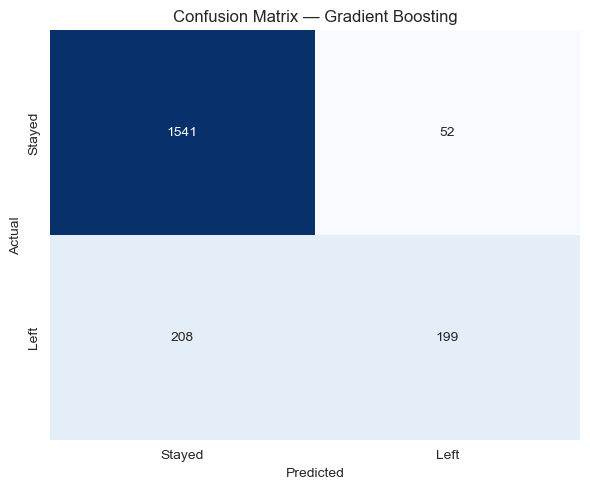


 Breakdown of 2000 test customers:
   Correctly predicted STAYED:  1541  (true negatives)
   Correctly predicted CHURNED: 199  (true positives — caught!)
    False alarms (predicted churn, but stayed):  52
   Missed churners (predicted stay, but left):  208


In [34]:
# Import confusion matrix function
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------------
# CONFUSION MATRIX — for the best model (Gradient Boosting)
# ---------------------------------------------------------------
# A confusion matrix shows the breakdown of correct vs incorrect predictions:
#
#                    Predicted: Stayed    Predicted: Left
#   Actual: Stayed   True Negative (TN)   False Positive (FP)
#   Actual: Left     False Negative (FN)  True Positive (TP)
#
# Why this matters for the bank:
#   - TP (caught churner)        → success! we can target retention
#   - FN (missed churner)        → BAD — customer leaves silently
#   - FP (false alarm)           → minor — we waste retention budget on a loyal customer
#   - TN (correct stay prediction) → no action needed
#
# In churn prediction, FALSE NEGATIVES are the most expensive mistake
# (you can't retain a customer you didn't know was leaving)

# Calculate confusion matrix using the best model's predictions
cm = confusion_matrix(y_test, y_pred_gb)

# Plot as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Left"],
            yticklabels=["Stayed", "Left"],
            cbar=False)
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Print a friendly business-style breakdown
tn, fp, fn, tp = cm.ravel()    # ravel flattens the 2x2 matrix into 4 numbers
print(f"\n Breakdown of {len(y_test)} test customers:")
print(f"   Correctly predicted STAYED:  {tn}  (true negatives)")
print(f"   Correctly predicted CHURNED: {tp}  (true positives — caught!)")
print(f"    False alarms (predicted churn, but stayed):  {fp}")
print(f"   Missed churners (predicted stay, but left):  {fn}")

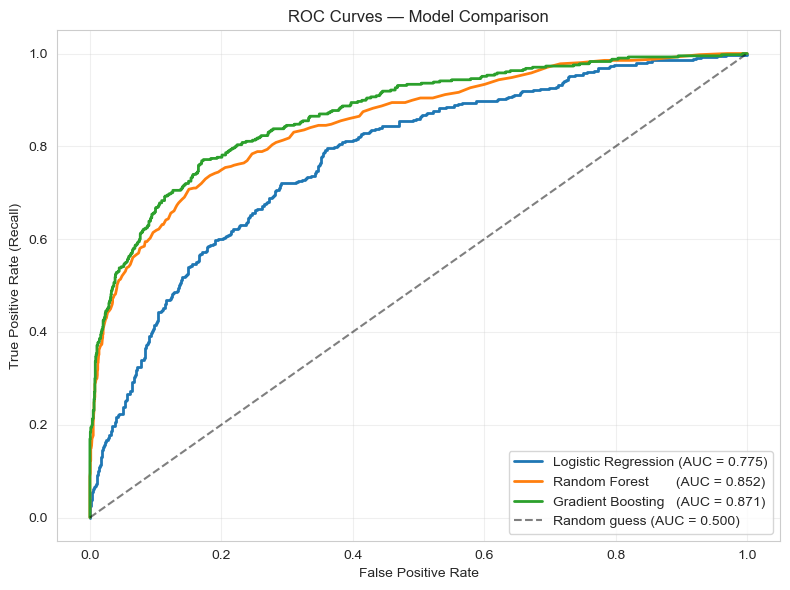

In [35]:
# Import ROC curve function
from sklearn.metrics import roc_curve

# ---------------------------------------------------------------
# ROC CURVES — visual comparison of all 3 models
# ---------------------------------------------------------------
# What is an ROC curve?
#   It plots True Positive Rate (Recall) vs False Positive Rate
#   at every possible classification threshold (not just 0.5)
#
# How to read it:
#   - The diagonal dashed line = random guessing (AUC = 0.5)
#   - Curves above the diagonal = better than random
#   - The further the curve bends toward the TOP-LEFT corner, the better
#   - AUC (Area Under Curve) gives a single number:
#       0.5  = random / useless
#       0.7-0.8 = decent
#       0.8-0.9 = good        ← our models are here!
#       0.9-1.0 = excellent

plt.figure(figsize=(8, 6))

# Calculate and plot ROC curve for each model
# roc_curve returns: false_positive_rate, true_positive_rate, thresholds
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

# Get the AUC values for the legend
auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_gb = roc_auc_score(y_test, y_proba_gb)

# Plot all three curves on the same axes
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest       (AUC = {auc_rf:.3f})", linewidth=2)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting   (AUC = {auc_gb:.3f})", linewidth=2)

# Add the diagonal "random guess" reference line
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Long format preview:
                 Model     Metric   Score
0  Logistic Regression   Accuracy  0.8080
1        Random Forest   Accuracy  0.8630
2    Gradient Boosting   Accuracy  0.8700
3  Logistic Regression  Precision  0.5891
4        Random Forest  Precision  0.7759
5    Gradient Boosting  Precision  0.7928
6  Logistic Regression     Recall  0.1867
7        Random Forest     Recall  0.4595


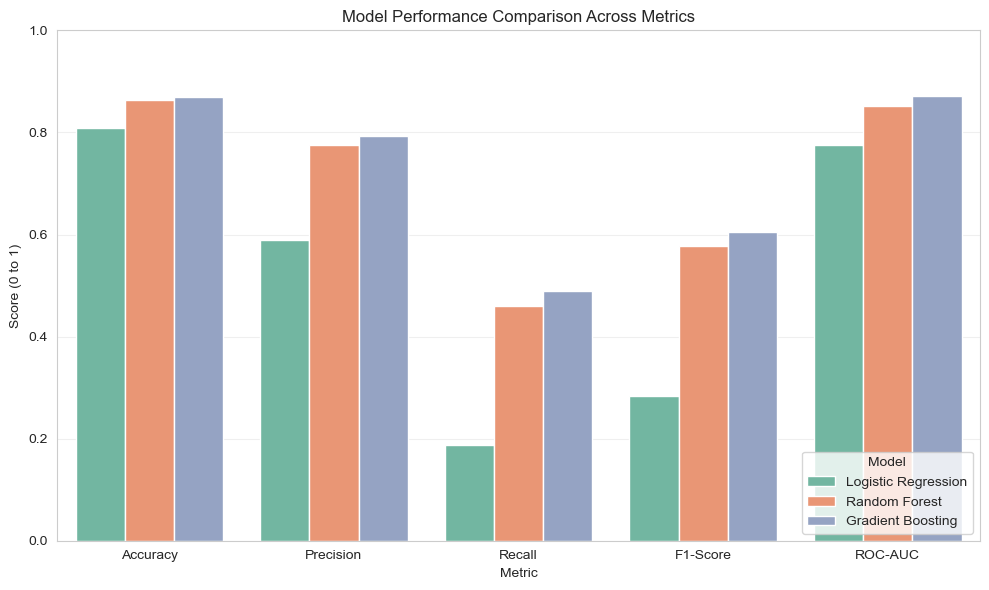

In [36]:
# ---------------------------------------------------------------
# METRICS COMPARISON BAR CHART
# ---------------------------------------------------------------
# Visual side-by-side comparison of all metrics for all models.
# This is the most "executive-friendly" plot — easy for non-technical
# stakeholders (like bank managers) to read at a glance.

# Reshape the results DataFrame from "wide" to "long" format for plotting
# Wide format: each metric is a column
# Long format: one column for the metric name, one column for the value
# Seaborn likes long format for grouped bar plots
metrics_long = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

print("Long format preview:")
print(metrics_long.head(8))

# Create the grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Model Performance Comparison Across Metrics")
plt.ylabel("Score (0 to 1)")
plt.ylim(0, 1)                              # set y-axis from 0 to 1 for fair comparison
plt.legend(loc="lower right", title="Model")
plt.grid(axis="y", alpha=0.3)              # horizontal grid lines for easier reading
plt.tight_layout()
plt.show()

## Step 6: Feature Importance Analysis

Knowing which model performs best is useful, but the real business value comes from understanding **why customers churn**. We extract feature importance scores from the Random Forest model to identify the top drivers of customer churn — these insights drive the business recommendations.

In [37]:
# ---------------------------------------------------------------
# FEATURE IMPORTANCE — what drives churn?
# ---------------------------------------------------------------
# Random Forest assigns an importance score to each feature based on how
# much it reduces prediction error across all trees. Higher = more important.
#
# Why use Random Forest (not Gradient Boosting) for this?
#   - Both can give feature importance, but RF is more interpretable
#   - The relative ranking is what matters, not the exact scores
#   - The patterns are usually similar across tree-based models
#
# Why this is the most important step for the BUSINESS:
#   - Predicting churn is good
#   - But knowing WHAT drives churn lets the bank fix the root causes
#   - This is the difference between treating symptoms and treating disease

# Extract feature importance from the trained Random Forest model
# rf.feature_importances_ is an array of importance scores (one per feature)
# X.columns gives us the matching feature names

importance_df = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# Display the ranked feature importances
print("Top drivers of customer churn (ranked):")
print("=" * 50)
print(importance_df.to_string(index=False))


Top drivers of customer churn (ranked):
          Feature  Importance
              Age    0.236846
  EstimatedSalary    0.147693
          Balance    0.142603
      CreditScore    0.142516
    NumOfProducts    0.129429
           Tenure    0.081576
   IsActiveMember    0.039721
Geography_Germany    0.028623
        HasCrCard    0.019008
      Gender_Male    0.018394
  Geography_Spain    0.013592


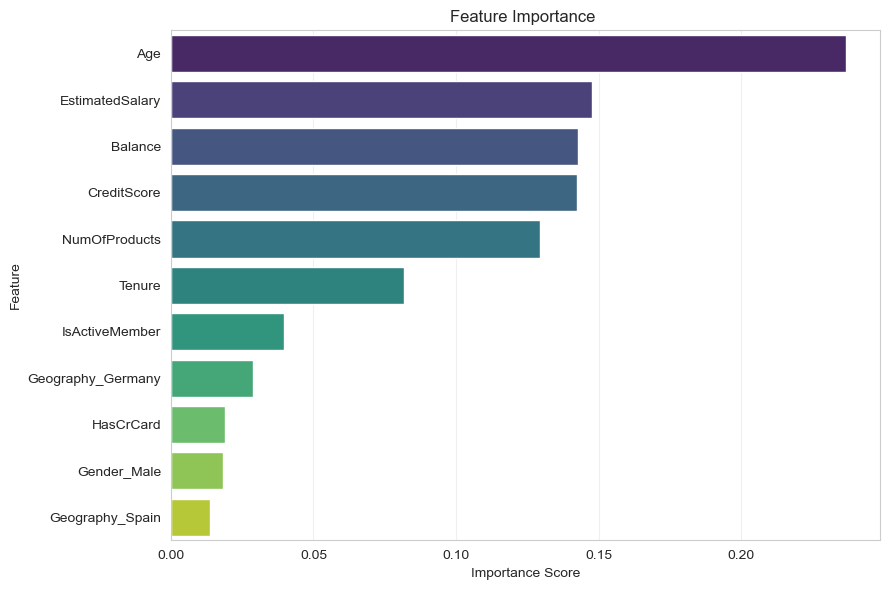

In [38]:
# ---------------------------------------------------------------
# FEATURE IMPORTANCE — VISUALISATION
# ---------------------------------------------------------------
# A horizontal bar chart is the cleanest way to show feature rankings.
# Why horizontal (not vertical)?
#   - Feature names can be long — they read better as labels on the y-axis
#   - It's easier to compare bar lengths than bar heights for ranking
#   - This is the standard format in research papers and business reports

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance ")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()